In [2]:
import numpy as np
import pandas as pd
import re
import random
import contractions
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from keras.models import Model
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SimpleRNN, Input, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from functions import preprocess, export_weights, export_matrix_to_mem

# Importação e processamento do Dataset

In [3]:
df = pd.read_csv("IMDB Dataset.csv")

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
random_num = random.randrange(len(df))

sample_text = df.iloc[random_num]['review']
sample_text

'A well-made and imaginative production, refreshingly free from cliché, this somewhat picaresque affair recounts a tale of a close friendship that develops between a man and a boy under less than ideal conditions: the man an escaped convict who has kidnapped the youth for his value as a hostage. Expertly directed by Alan Gibson with a fine sense for balanced narrative movement, the film provides freshness in nearly every scene, as felon Martin Steckert (Richard Harris), believing that his rejection for parole was particularly undeserved, contrives a convoluted but ultimately successful escape plan, following which his spontaneous nature comes to the fore as he flees to the lakeside residence of his childhood. Often bursting into song or dancing a few steps, the capricious Steckert gradually gains the trust and affection of his captive and, as police close in for an inevitable showdown, the tethered pair are seen to be a great deal alike in their responses to forms of rejection, as disc

In [6]:
print(preprocess(df.iloc[random_num]['review']))

well made imaginative production refreshingly free cliché somewhat picaresque affair recount tale close friendship develops man boy less ideal condition man escaped convict kidnapped youth value hostage expertly directed alan gibson fine sense balanced narrative movement film provides freshness nearly every scene felon martin steckert richard harris believing rejection parole particularly undeserved contrives convoluted ultimately successful escape plan following spontaneous nature come fore flees lakeside residence childhood often bursting song dancing step capricious steckert gradually gain trust affection captive police close inevitable showdown tethered pair seen great deal alike response form rejection discerned psychiatrist lindsay wagner assigned aid zealous police lieutenant james coburn charge manhunt steckert prisoner engrossing story worth telling quickly paced novel adventure profit capital performance harris fine turn wagner coburn karen black along justin henry snatched l

In [7]:
df['review'] = df['review'].apply(preprocess)

In [8]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [9]:
n_words = [len(i.split(" ")) for i in df['review']]
print(f"Quantidade média de tokens {np.mean(n_words)}")
print(f"Mediana de tokens {np.median(n_words)}")

Quantidade média de tokens 116.49538
Mediana de tokens 86.0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [11]:
vocab_size = 20000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<UNK>")
tokenizer.fit_on_texts(X_train)

In [12]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
max_len = 120

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# LSTM

In [14]:
lstm_model = Sequential()

lstm_model.add(Input(shape=(max_len,)))

lstm_model.add(Embedding(input_dim=vocab_size, output_dim=4))
lstm_model.add(SpatialDropout1D(0.3))

lstm_model.add((LSTM(16, dropout=0.3)))

lstm_model.add(Dropout(0.5))

lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dropout(0.4))

lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

lstm_model.build(input_shape=(None, max_len))
lstm_model.summary()

2026-06-14 21:11:45.093426: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 4)         │        80,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 120, 4)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,921 (320.00 KB)

 Trainable params: 81,921 (320.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [16]:
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=100,
    batch_size=128,   
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5641 - loss: 0.6742 - val_accuracy: 0.7941 - val_loss: 0.5429 - learning_rate: 5.0000e-04
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8033 - loss: 0.4483 - val_accuracy: 0.8606 - val_loss: 0.3330 - learning_rate: 5.0000e-04
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8571 - loss: 0.3401 - val_accuracy: 0.8735 - val_loss: 0.3014 - learning_rate: 5.0000e-04
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8736 - loss: 0.3014 - val_accuracy: 0.8783 - val_loss: 0.2926 - learning_rate: 5.0000e-04
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8894 - loss: 0.2698 - val_accuracy: 0.8783 - val_loss: 0.3198 - learning_rate: 5.0000e-04


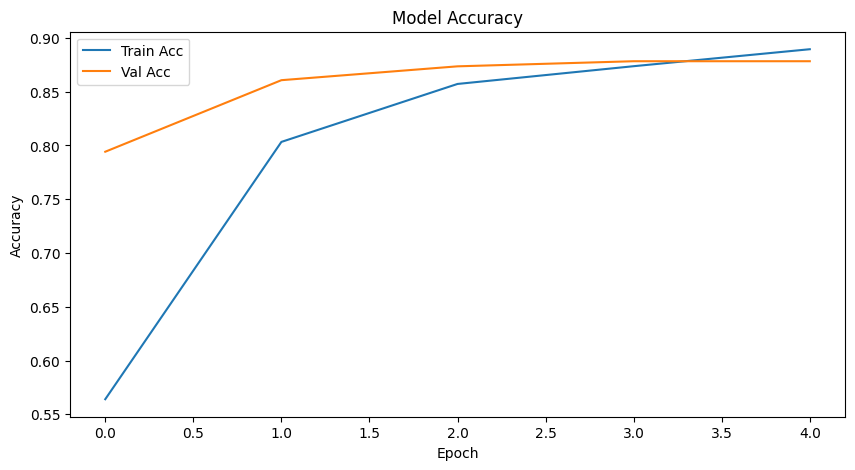

In [17]:
plt.figure(figsize=(10,5))

plt.plot(lstm_history.history['accuracy'], label='Train Acc')
plt.plot(lstm_history.history['val_accuracy'], label='Val Acc')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [18]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print("Test Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8820 - loss: 0.2804
Test Accuracy: 0.8820000290870667


# Matriz de Confusão

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


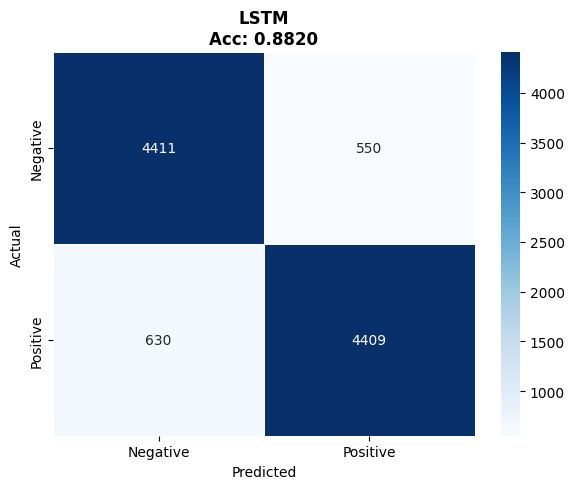

In [19]:
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive'],
    linewidths=0.5,
    linecolor='white'
)

acc = (y_pred_lstm == y_test.values).mean()

plt.title(f'LSTM\nAcc: {acc:.4f}', fontsize=12, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

# Resultados da Classificação

In [20]:
for name, pred in zip(['LSTM'], [ y_pred_lstm]):
    print(f"{'='*45}")
    print(f"  {name} — Classification Report")
    print(f"{'='*45}")
    print(classification_report(y_test, pred, target_names=['Negative','Positive']))

  LSTM — Classification Report
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.88      4961
    Positive       0.89      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



# Exportação de Pesos

In [21]:
export_weights(lstm_model, mode='lstm', output_file="weights_lstm_big.mem")


print("\n" + "#"*60)
print("CONCLUIDO!")
print("#"*60)


MODO LSTM: Exportando pesos a partir da primeira LSTM
Ignorando: Embedding e SpatialDropout1D

Camada 0: LSTM
  addr=0x08000 Wx_candidate[0][0] = 0.063757
  addr=0x08001 Wx_candidate[0][1] = 0.270667
  addr=0x08080 Wx_candidate[1][0] = 0.281828
  addr=0x08081 Wx_candidate[1][1] = -0.092224
  addr=0x08040 Wh_candidate[0][0] = 0.006382
  addr=0x08041 Wh_candidate[0][1] = 0.175127
  addr=0x080C0 Wh_candidate[1][0] = -0.117408
  addr=0x080C1 Wh_candidate[1][1] = 0.207923
  addr=0x18000 bias_candidate[0] = 0.096154
  addr=0x18080 bias_candidate[1] = 0.070815
  addr=0x0A000 Wx_forget[0][0] = 0.285772
  addr=0x0A001 Wx_forget[0][1] = 0.320276
  addr=0x0A080 Wx_forget[1][0] = 0.421672
  addr=0x0A081 Wx_forget[1][1] = -0.245707
  addr=0x0A040 Wh_forget[0][0] = 0.038015
  addr=0x0A041 Wh_forget[0][1] = 0.026071
  addr=0x0A0C0 Wh_forget[1][0] = -0.016823
  addr=0x0A0C1 Wh_forget[1][1] = -0.115835
  addr=0x1A000 bias_forget[0] = 1.061832
  addr=0x1A080 bias_forget[1] = 1.044833
  addr=0x0C000 Wx_

# Geração de teste único

In [22]:
texto_natural = "the was probaly the worst movie that I have seen"
texto_sem_stopwords = preprocess(texto_natural)
print(texto_sem_stopwords)

probaly worst movie seen


In [23]:
teste_qualquer = tokenizer.texts_to_sequences([texto_sem_stopwords])
teste_qualquer_pad = pad_sequences(teste_qualquer, maxlen=max_len)

In [24]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = teste_qualquer_pad

outputs = inspection_model.predict(x)

# salva em txt
with open("layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
Outputs salvos em layer_outputs_simplified_model.txt


# Teste Global

In [49]:
dummy = tf.zeros((1, max_len), dtype=tf.int32)
_ = lstm_model(dummy)

layer_outputs = [layer.output for layer in lstm_model.layers]

inspection_model = Model(
    inputs=lstm_model.inputs,
    outputs=layer_outputs
)

x = np.array([X_test_pad[0].tolist()])

outputs = inspection_model.predict(x)

# salva em txt
with open("Global Processing/layer_outputs_simplified_model.txt", "w", encoding="utf-8") as f:

    for layer, output in zip(lstm_model.layers, outputs):

        f.write(f"\n{'='*60}\n")
        f.write(f"Camada: {layer.name}\n")
        f.write(f"Shape: {output.shape}\n")
        f.write(f"{'='*60}\n\n")

        # converte numpy array para string
        np.set_printoptions(threshold=np.inf)

        f.write(np.array2string(
            output,
            separator=', ',
            precision=6
        ))

        f.write("\n\n")

print("Outputs salvos em layer_outputs_simplified_model.txt")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
Outputs salvos em layer_outputs_simplified_model.txt


In [26]:
len(outputs[0][0])

120

In [29]:
FRAC = 16
SCALE = 1 << FRAC

INT32_MAX = np.int32(2**31 - 1)
INT32_MIN = np.int32(-(2**31))

def float_to_q16(val):
    if np.isnan(val):
        return np.int32(0)
    if np.isposinf(val):
        return INT32_MAX
    if np.isneginf(val):
        return INT32_MIN
    fixed = np.round(val * SCALE)
    return np.int32(fixed)


In [68]:
def export_matrix_to_mem(matrix,result,ground_result, output_file="matrix.mem"):
    mem = {}
    
    for linha_idx in range(matrix.shape[0]):
        for col_idx in range(4):
            addr = (linha_idx << 2) | col_idx
            valor = matrix[linha_idx, col_idx]
            valor_q16 = float_to_q16(valor)  # sua função original
            mem[addr] = valor_q16
    
    # ESCREVE EXATAMENTE COMO NO SEU CÓDIGO ORIGINAL
    with open(output_file, "w") as f:
        line = 0
        result_hex = float_to_q16(result)
        if result<.5:
            v = 0
        else:
            v = 2
        flag = ground_result+v
        for addr in sorted(mem.keys()):
            val = np.int32(mem[addr])  # ← igual ao original
            if line == 0:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X} {int(result_hex) & 0xFFFFFFFF:08X}  {int(flag) & 0xFFFFFFFF:01X}   \n")
            else:
                f.write(f"{int(addr):05x} {int(val) & 0xFFFFFFFF:08X}\n")
            line+=1
    print(f"Arquivo salvo: {output_file}")
    return mem

In [61]:
outputs[0][0].shape

(120, 4)

In [62]:
y_test.values[0]

np.int64(1)

In [69]:
export_matrix_to_mem(outputs[0][0], outputs[6][0][0], y_test.values[0], "meus_dados.mem")


Arquivo salvo: meus_dados.mem


{0: 33,
 1: -87,
 2: -170,
 3: 524,
 4: 33,
 5: -87,
 6: -170,
 7: 524,
 8: 33,
 9: -87,
 10: -170,
 11: 524,
 12: 33,
 13: -87,
 14: -170,
 15: 524,
 16: 33,
 17: -87,
 18: -170,
 19: 524,
 20: 33,
 21: -87,
 22: -170,
 23: 524,
 24: 33,
 25: -87,
 26: -170,
 27: 524,
 28: 33,
 29: -87,
 30: -170,
 31: 524,
 32: 33,
 33: -87,
 34: -170,
 35: 524,
 36: 33,
 37: -87,
 38: -170,
 39: 524,
 40: 33,
 41: -87,
 42: -170,
 43: 524,
 44: 638,
 45: 172,
 46: 177,
 47: 245,
 48: -5756,
 49: 4480,
 50: -5400,
 51: -3467,
 52: 87,
 53: -1134,
 54: 49,
 55: 183,
 56: -1688,
 57: 2484,
 58: -3801,
 59: 633,
 60: 322,
 61: -2229,
 62: 3096,
 63: 1283,
 64: 1913,
 65: -1562,
 66: 2446,
 67: 2880,
 68: -635,
 69: 2031,
 70: -2763,
 71: -2045,
 72: 322,
 73: -2229,
 74: 3096,
 75: 1283,
 76: -2762,
 77: 1710,
 78: -2701,
 79: -4654,
 80: 2842,
 81: -6082,
 82: 4161,
 83: 3559,
 84: 3755,
 85: -6982,
 86: 2315,
 87: 4361,
 88: -2127,
 89: -379,
 90: -1248,
 91: 791,
 92: 1389,
 93: -2430,
 94: 1551,
 95